In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your CSV file
df = pd.read_csv('internship_big_data.csv')

# Quick check
print(df.shape)
print(df.head())
print(df['Status'].value_counts())

(1000, 14)
  Intern_ID      Name  Age  Gender Education_Level    Location   Department  \
0   INT0001  Intern_1   27    Male   Undergraduate   Islamabad    Marketing   
1   INT0002  Intern_2   27    Male   Undergraduate     Karachi           IT   
2   INT0003  Intern_3   22  Female        Graduate      Quetta  Engineering   
3   INT0004  Intern_4   25  Female   Undergraduate  Bahawalpur    Marketing   
4   INT0005  Intern_5   20    Male   Undergraduate    Peshawar        Legal   

   Duration Stipend Mentor_Assigned  Mentor_Meetings  Tasks_Completed  \
0   1 Month    Paid              No                0                6   
1   1 Month    Paid             Yes               13               15   
2   1 Month    Paid             Yes               10                7   
3  3 Months    Paid              No                0                6   
4  3 Months  Unpaid             Yes                7                7   

   Attendance_%     Status  
0          79.5  Completed  
1          72.5  

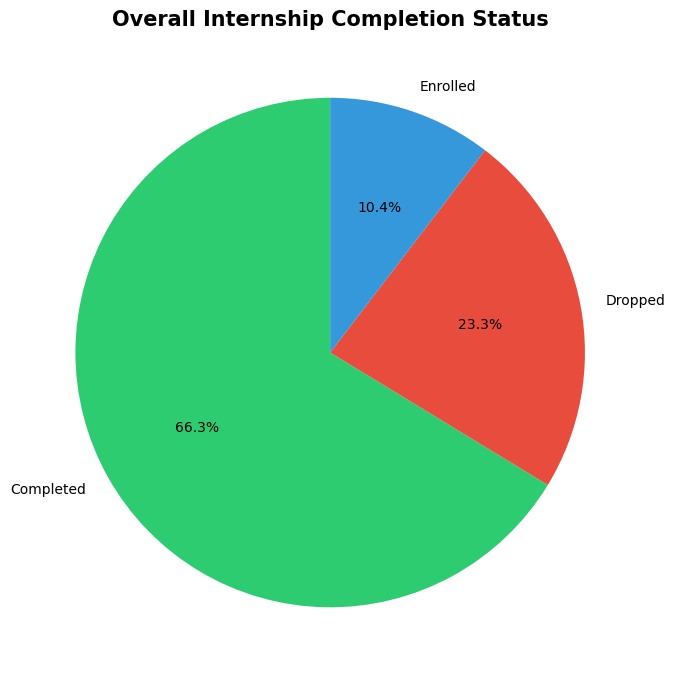

In [2]:
plt.figure(figsize=(7, 7))
status_counts = df['Status'].value_counts()
colors = ['#2ecc71', '#e74c3c', '#3498db']
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%',
        colors=colors, startangle=90)
plt.title('Overall Internship Completion Status', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('chart1_overall.png', dpi=150)
plt.show()

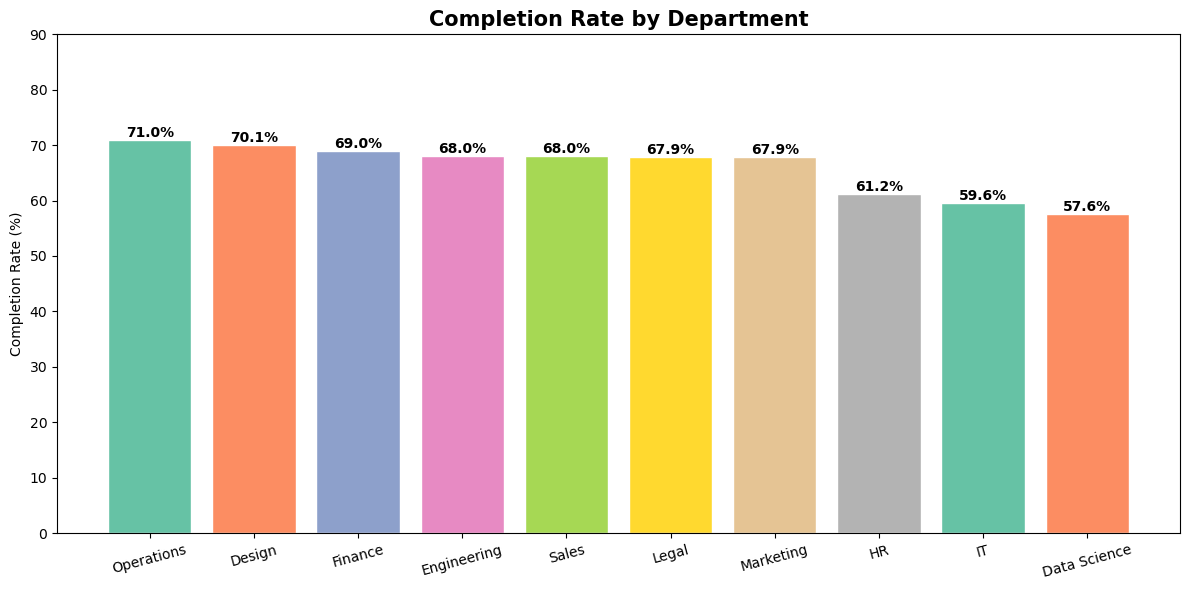

In [3]:
dept = df.groupby('Department')['Status'].value_counts().unstack(fill_value=0)
dept['Completion_%'] = (dept['Completed'] / dept.sum(axis=1) * 100).round(1)
dept = dept.sort_values('Completion_%', ascending=False)

plt.figure(figsize=(12, 6))
bars = plt.bar(dept.index, dept['Completion_%'],
               color=sns.color_palette('Set2', len(dept)), edgecolor='white')
for bar, val in zip(bars, dept['Completion_%']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val}%', ha='center', fontsize=10, fontweight='bold')
plt.title('Completion Rate by Department', fontsize=15, fontweight='bold')
plt.ylabel('Completion Rate (%)')
plt.ylim(0, 90)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('chart2_department.png', dpi=150)
plt.show()

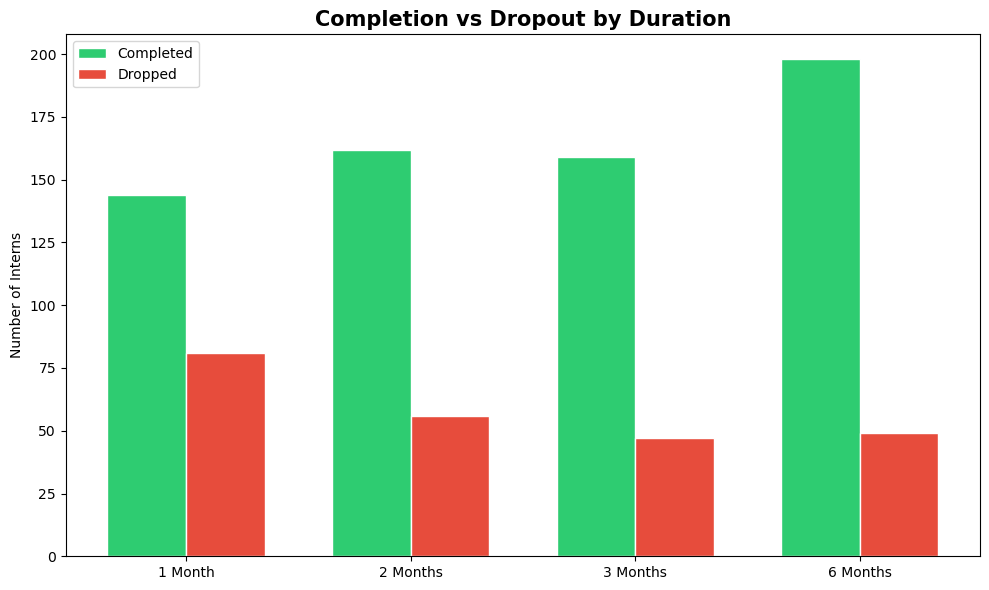

In [4]:
dur = df.groupby('Duration')['Status'].value_counts().unstack(fill_value=0)
dur = dur.reindex(['1 Month', '2 Months', '3 Months', '6 Months'])

x = range(len(dur))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar([i - width/2 for i in x], dur['Completed'], width,
        label='Completed', color='#2ecc71', edgecolor='white')
plt.bar([i + width/2 for i in x], dur['Dropped'], width,
        label='Dropped', color='#e74c3c', edgecolor='white')
plt.xticks(list(x), dur.index)
plt.title('Completion vs Dropout by Duration', fontsize=15, fontweight='bold')
plt.ylabel('Number of Interns')
plt.legend()
plt.tight_layout()
plt.savefig('chart3_duration.png', dpi=150)
plt.show()

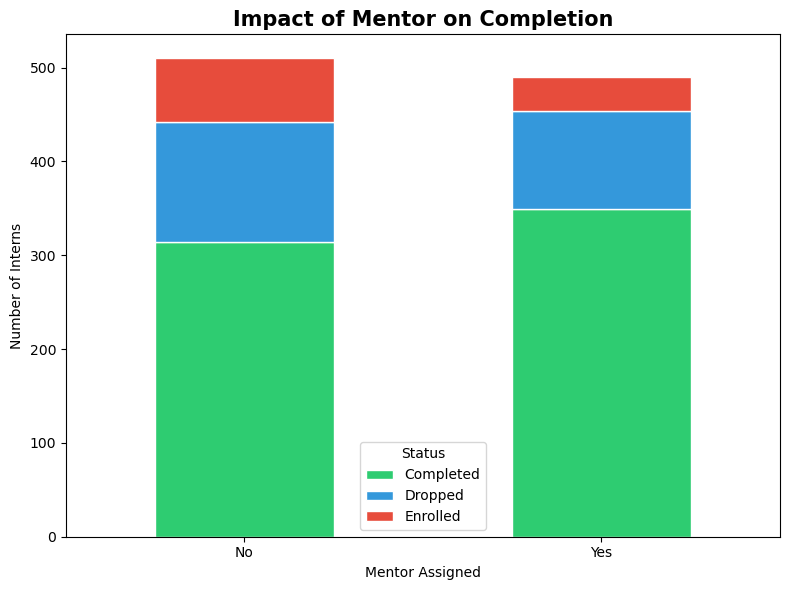

In [5]:
mentor = df.groupby('Mentor_Assigned')['Status'].value_counts().unstack(fill_value=0)

mentor.plot(kind='bar', stacked=True, figsize=(8, 6),
            color=['#2ecc71', '#3498db', '#e74c3c'], edgecolor='white')
plt.title('Impact of Mentor on Completion', fontsize=15, fontweight='bold')
plt.ylabel('Number of Interns')
plt.xlabel('Mentor Assigned')
plt.xticks(rotation=0)
plt.legend(title='Status')
plt.tight_layout()
plt.savefig('chart4_mentor.png', dpi=150)
plt.show()

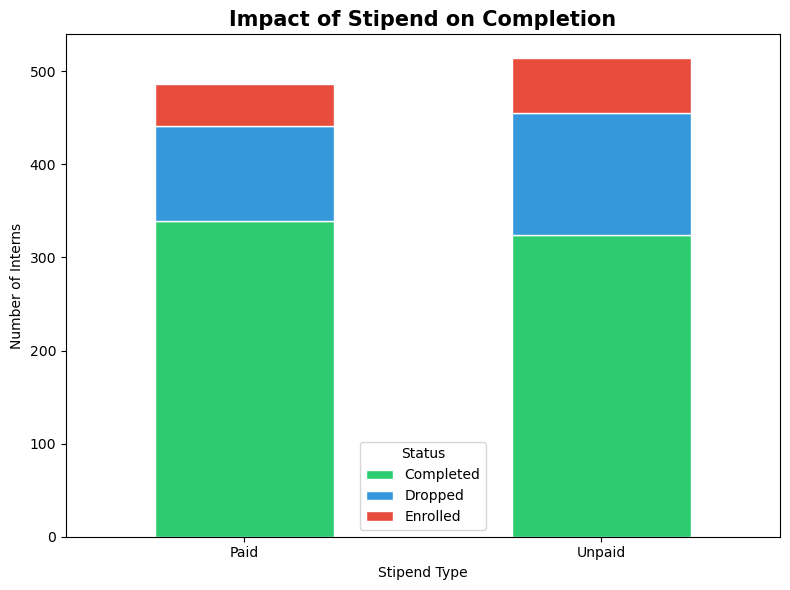

In [6]:
stip = df.groupby('Stipend')['Status'].value_counts().unstack(fill_value=0)

stip.plot(kind='bar', stacked=True, figsize=(8, 6),
          color=['#2ecc71', '#3498db', '#e74c3c'], edgecolor='white')
plt.title('Impact of Stipend on Completion', fontsize=15, fontweight='bold')
plt.ylabel('Number of Interns')
plt.xlabel('Stipend Type')
plt.xticks(rotation=0)
plt.legend(title='Status')
plt.tight_layout()
plt.savefig('chart5_stipend.png', dpi=150)
plt.show()